In [80]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 

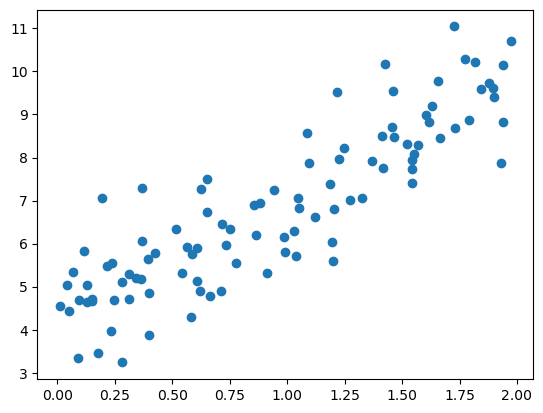

In [81]:
m = 100 
np.random.seed(42)
X = 2 * np.random.rand(m, 1) # uniform distribution
y = 4 + 3 * X + np.random.randn(m, 1) # from gaussian distribution
plt.scatter(X, y)

In [82]:
from sklearn.preprocessing import add_dummy_feature

X_b = add_dummy_feature(X)  # add x0 = 1 to each instance
theta_best = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y

In [83]:
theta_best

array([[4.21509616],
       [2.77011339]])

In [84]:
X_new= np.array([[0], [2]])
X_new = add_dummy_feature(X_new)
X_new

array([[1., 0.],
       [1., 2.]])

In [85]:
y_predict= X_new @ theta_best

In [86]:
y_predict

array([[4.21509616],
       [9.75532293]])

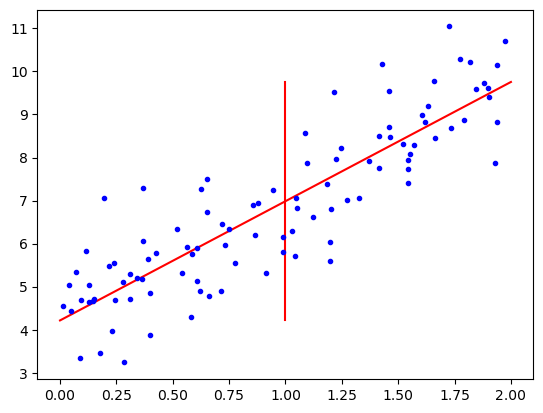

In [87]:
plt.plot(X_new, y_predict, 'r-')
plt.plot(X, y, 'b.')

In [88]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X_b, y)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [89]:
lin_reg.intercept_

array([4.21509616])

In [90]:
lin_reg.coef_

array([[0.        , 2.77011339]])

In [91]:
lin_reg.predict(X_new)

array([[4.21509616],
       [9.75532293]])

In [92]:
eta = 0.1
n_epochs = 1000
m = len(X_b)

np.random.seed(42)
theta = np.random.randn(2, 1)

for i in range(n_epochs):
    grads = (2 / m) * X_b.T @ (X_b @ theta - y)
    theta = theta - eta * grads 
theta 

array([[4.21509616],
       [2.77011339]])

In [93]:
n_epochs = 50 
t0, t1 = 5, 50
eta = 0.1
def learning_schedule(t):
    return t0 / (t + t1)
np.random.seed(42)
theta = np.random.randn(2,1)

for epoch in range(n_epochs):
    for iteration in range(m):
        rand_idx = np.random.randint(m)
        x_indx = X_b[rand_idx: rand_idx+1]
        y_indx = y[rand_idx: rand_idx+1]
        grads = 2 * x_indx.T @ (x_indx @ theta - y_indx)
        eta = learning_schedule(epoch * m + iteration)
        theta = theta - eta * grads 
theta 



array([[4.21076011],
       [2.74856079]])

In [94]:
from sklearn.linear_model import SGDRegressor

sgd_reg = SGDRegressor(max_iter=1000, tol = 1e-5, penalty=None, eta0 = 0.01, n_iter_no_change=100, random_state=42 )

In [95]:
sgd_reg.fit(X, y.ravel())

,loss,'squared_error'
,penalty,None
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,1000
,tol,1e-05
,shuffle,True
,verbose,0
,epsilon,0.1
,random_state,42


In [96]:
sgd_reg.intercept_, sgd_reg.coef_

(array([4.21278812]), array([2.77270267]))

In [97]:
np.random.seed(42)
m = 100
X = 6 * np.random.rand(m, 1) - 3 
y = 0.5 * X ** 2 + X + 2 + np.random.randn(m, 1)

In [98]:
from sklearn.preprocessing import PolynomialFeatures
poly_features = PolynomialFeatures(degree = 2, include_bias=False)

X_poly = poly_features.fit_transform(X)
print(X[0])
print(X_poly[0])

[-0.75275929]
[-0.75275929  0.56664654]


In [99]:
lin_reg = LinearRegression()
lin_reg.fit(X_poly, y)
lin_reg.intercept_, lin_reg.coef_

(array([1.78134581]), array([[0.93366893, 0.56456263]]))

In [100]:
from sklearn.linear_model import SGDRegressor

sgd_reg = SGDRegressor(max_iter=1000, penalty="l2", eta0 = 0.01,random_state=42, alpha = 0.1 / m )
sgd_reg.fit(X, y.ravel())
sgd_reg.predict([[1.5]])



array([4.81938628])

In [101]:
from sklearn.datasets import load_iris
iris = load_iris(as_frame=True)
list(iris) 

['data',
 'target',
 'frame',
 'target_names',
 'DESCR',
 'feature_names',
 'filename',
 'data_module']

In [102]:
iris.data.head(3)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2


In [103]:
iris.target.head(3)

0    0
1    0
2    0
Name: target, dtype: int64

In [104]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [105]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

X = iris.data[['petal width (cm)']].values
y = iris.target_names[iris.target] == 'virginica'

x_train, x_test, y_train, y_test = train_test_split(X, y, random_state= 42)
logs_reg = LogisticRegression()
logs_reg.fit(x_train, y_train)



,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [106]:
y_train

array([False, False,  True, False, False, False, False, False,  True,
        True, False,  True, False,  True, False, False,  True, False,
       False, False, False, False,  True, False, False, False, False,
       False, False,  True, False, False,  True, False,  True,  True,
       False, False,  True, False, False, False,  True, False, False,
       False, False, False,  True, False, False, False, False,  True,
       False,  True,  True, False, False, False,  True,  True, False,
       False, False, False,  True, False,  True,  True, False, False,
       False,  True, False,  True, False,  True, False,  True, False,
       False, False, False, False, False, False, False,  True,  True,
       False, False,  True,  True, False,  True, False, False,  True,
        True, False,  True, False, False,  True,  True, False, False,
        True, False, False,  True])

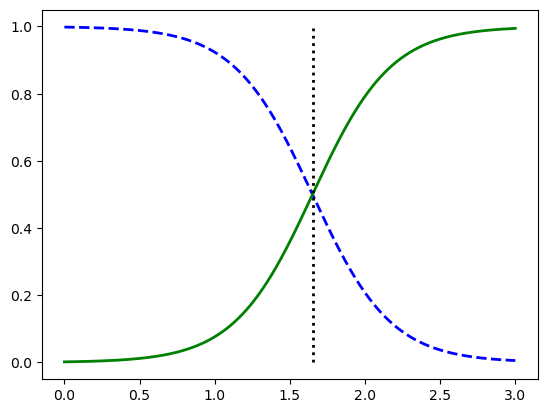

In [107]:
X_new = np.linspace(0, 3, 1000).reshape(-1, 1)
y_proba =  logs_reg.predict_proba(X_new)
decision_boundary = X_new[y_proba[:, 1] >=0.5][0, 0]

plt.plot(X_new, y_proba[:, 0], "b--", linewidth = 2, label = "not iris virginica probas")
plt.plot(X_new, y_proba[:, 1], "g-", linewidth = 2, label = "iris virginica probas")
plt.plot([decision_boundary, decision_boundary], [0,1], "k:", linewidth = 2, label = "decision boundary")


In [109]:
X = iris.data[['petal length (cm)', 'petal width (cm)']].values 
y = iris['target']

x_train, x_test, y_train, y_test = train_test_split(X, y, random_state= 42)
softmax_reg = LogisticRegression(C = 30, random_state=42)
softmax_reg.fit(x_train, y_train)




,penalty,'l2'
,dual,False
,tol,0.0001
,C,30
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [120]:
x_train.shape 

(112, 2)

In [110]:
softmax_reg.predict([[5, 2]])

array([2])

In [111]:
softmax_reg.predict_proba([[5,2]]).round(2)

array([[0.  , 0.04, 0.96]])

- Implement batch gradient descent with softmax from scratch without sklearn


In [147]:
X = iris.data[['petal length (cm)', 'petal width (cm)']].values 
y = iris['target']

In [148]:
# add a bias term 
ones = np.ones(X.shape[0])
X = np.c_[ones, X]


In [183]:
val_ratio, test_ratio = 0.2, 0.2 
data_size = len(X)
val_size, test_size = int(val_ratio * data_size), int(test_ratio * data_size)
train_size = data_size - (val_size + test_size)
# shuffle X and y simulatenously 
np.random.seed(42)
indices = np.random.permutation(data_size)
# split the data 
x_train = X[indices[:train_size]]
y_train = y[indices[:train_size]]
x_val = X[indices[train_size: -test_size]]
y_val = y[indices[train_size: -test_size]]
x_test = X[indices[-test_size:]]
y_test = y[indices[-test_size:]]




In [184]:
def to_one_hot(y):
    return np.diag(np.ones(y.max() + 1))[y]

In [185]:
to_one_hot(y_train[:10])

array([[0., 1., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 1., 0.]])

In [186]:
y_train_hot = to_one_hot(y_train)
y_val_hot = to_one_hot(y_val)
y_test_hot = to_one_hot(y_test)


In [188]:
X

array([[1. , 1.4, 0.2],
       [1. , 1.4, 0.2],
       [1. , 1.3, 0.2],
       [1. , 1.5, 0.2],
       [1. , 1.4, 0.2],
       [1. , 1.7, 0.4],
       [1. , 1.4, 0.3],
       [1. , 1.5, 0.2],
       [1. , 1.4, 0.2],
       [1. , 1.5, 0.1],
       [1. , 1.5, 0.2],
       [1. , 1.6, 0.2],
       [1. , 1.4, 0.1],
       [1. , 1.1, 0.1],
       [1. , 1.2, 0.2],
       [1. , 1.5, 0.4],
       [1. , 1.3, 0.4],
       [1. , 1.4, 0.3],
       [1. , 1.7, 0.3],
       [1. , 1.5, 0.3],
       [1. , 1.7, 0.2],
       [1. , 1.5, 0.4],
       [1. , 1. , 0.2],
       [1. , 1.7, 0.5],
       [1. , 1.9, 0.2],
       [1. , 1.6, 0.2],
       [1. , 1.6, 0.4],
       [1. , 1.5, 0.2],
       [1. , 1.4, 0.2],
       [1. , 1.6, 0.2],
       [1. , 1.6, 0.2],
       [1. , 1.5, 0.4],
       [1. , 1.5, 0.1],
       [1. , 1.4, 0.2],
       [1. , 1.5, 0.2],
       [1. , 1.2, 0.2],
       [1. , 1.3, 0.2],
       [1. , 1.4, 0.1],
       [1. , 1.3, 0.2],
       [1. , 1.5, 0.2],
       [1. , 1.3, 0.3],
       [1. , 1.3

In [189]:
mean = X[:, 1:].mean(axis = 0)
std = X[:, 1:].std(axis = 0)

x_train[:, 1:] = (x_train[:, 1:] - mean) / std
x_val[:, 1:] = (x_val[:, 1:] - mean) / std 
x_test[:, 1:] = (x_test[:, 1:] - mean) / std 


In [211]:
def softmax(logits):
    exps = np.exp(logits)
    exps_sum = exps.sum(axis =1, keepdims = True)
    return exps / exps_sum

In [251]:
n_inputs, n_outputs = x_train.shape[1], len(np.unique(y)) # features * classes 
np.random.seed(42)
theta = np.random.randn(n_inputs, n_outputs)
theta 

array([[ 0.49671415, -0.1382643 ,  0.64768854],
       [ 1.52302986, -0.23415337, -0.23413696],
       [ 1.57921282,  0.76743473, -0.46947439]])

In [213]:
y_train.shape 

(90,)

In [262]:
n_epochs = 5001
eta = 0.5 
eps = 1e-5
C = 100
m = len(x_train)
prev_loss = np.inf 
theta = np.random.randn(n_inputs, n_outputs)
for epoch in range(n_epochs):
    logits = x_train @ theta 
    y_val_proba = softmax(x_val @ theta)
    cross_entropy_loss = - (y_val_hot * np.log(y_val_proba +eps ))
    l2_loss = 1 / 2 * (theta[1: ] ** 2).sum()
    total_loss = cross_entropy_loss.sum(axis =1).mean() + 1 / C * l2_loss
    print(f"total loss for epoch {epoch} is: {total_loss}")
    if total_loss > prev_loss:
        break 
    prev_loss = total_loss
    error = softmax(logits) - y_train_hot 
    gradients = 1 /m * x_train.T @ error
    theta = theta - eta * gradients
theta 

total loss for epoch 0 is: 2.0069883274044376
total loss for epoch 1 is: 1.6829374304245612
total loss for epoch 2 is: 1.4136466321120713
total loss for epoch 3 is: 1.1930783207482276
total loss for epoch 4 is: 1.0225484996122949
total loss for epoch 5 is: 0.8996933506211148
total loss for epoch 6 is: 0.8151354944748881
total loss for epoch 7 is: 0.7564488467077967
total loss for epoch 8 is: 0.7134306260390054
total loss for epoch 9 is: 0.6796577652938179
total loss for epoch 10 is: 0.651554298329448
total loss for epoch 11 is: 0.6271955989894702
total loss for epoch 12 is: 0.6055302468788301
total loss for epoch 13 is: 0.5859591418796396
total loss for epoch 14 is: 0.5681196961714242
total loss for epoch 15 is: 0.5517756463634338
total loss for epoch 16 is: 0.5367599875293317
total loss for epoch 17 is: 0.5229448343074542
total loss for epoch 18 is: 0.5102252060868441
total loss for epoch 19 is: 0.49851018837940697
total loss for epoch 20 is: 0.48771809772476993
total loss for epoch 2

array([[-0.79339375,  1.40851056, -1.13175123],
       [-2.11582663,  1.04809765,  2.30480332],
       [-2.26344462, -1.01012972,  1.81756468]])

In [263]:
logits = x_val @ theta 
y_probas = softmax(logits)
y_predict = y_probas.argmax(axis = 1)

accuracy = (y_predict == y_val).mean()
accuracy


0.9333333333333333

In [ ]:
# check test accuracy 
logits = x_test @ theta 
y_probas  = softmax(logits)
y_predict = y_probas.argmax(axis = 1)

accuracy = (y_predict == y_test).mean()
accuracy


0.9666666666666667

Got better accuracy for testing than validation, perhaps because the size of the data isn't too large